#Thresholding
Thresholding transforms images into binary images.
For every pixel, the same threshold value is applied. If the pixel value is smaller than the threshold, it is set to 0, otherwise it is set to a maximum value. So we need to set the threshold value and max value and then we convert the pixel values accordingly.
To apply thresholding we have to first convert the color image in a grayscale image.

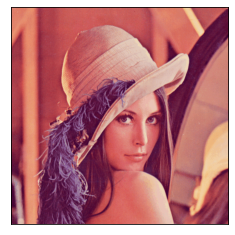

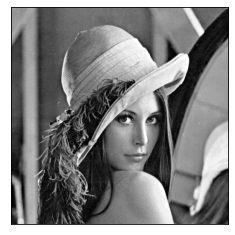

In [2]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


img=mpimg.imread('lena_color.gif')
imgplot = plt.imshow(img)
plt.show(plt.xticks([]), plt.yticks([])) 
#We need to convert the color mode to grayscale to apply thresholding
src = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(src, cmap = 'gray')
plt.show(plt.xticks([]), plt.yticks([]))

The function `cv.threshold()` is used to apply the thresholding. The method returns two outputs: the threshold that was used and the thresholded image.
The first argument is the source image, which should be a grayscale image. The second argument is the threshold value which is used to classify the pixel values. The third argument is the maximum value which is assigned to pixel values exceeding the threshold. 
OpenCV provides different types of thresholding which is given by the fourth parameter of the function. Basic thresholding as described above is done by using the type `cv2.THRESH_BINARY`.



min= 25
max= 207


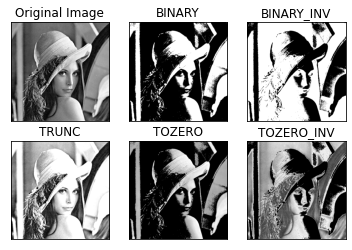

In [3]:
# Thresholding with maxval=255
T=127
maxval=255
minvalue=np.min(src)
maxvalue=np.max(src)
print('min=',minvalue)
print('max=',maxvalue)
#simple binary thresholding
# if 𝚜𝚛𝚌(x,y)>T then dst(x,y)= maxval else dst(x,y)=0
th1,dst1 = cv2.threshold(src,T,maxval,cv2.THRESH_BINARY)

#inverse of simple binary thresholding
# if 𝚜𝚛𝚌(x,y)>T then dst(x,y)=0 else dst(x,y)= maxval 
th2,dst2 = cv2.threshold(src,T,maxval,cv2.THRESH_BINARY_INV)

#truncated thresholding
# if 𝚜𝚛𝚌(x,y)>T then dst(x,y)= T else dst(x,y)=𝚜𝚛𝚌(x,y) 
th3,dst3 = cv2.threshold(src,T,maxval,cv2.THRESH_TRUNC)

#thresholding to zero
# if 𝚜𝚛𝚌(x,y)>T then dst(x,y)=𝚜𝚛𝚌(x,y) else dst(x,y)= 0 
th4,dst4 = cv2.threshold(src,T,maxval,cv2.THRESH_TOZERO)

# inverse of thresholding to zero
# if 𝚜𝚛𝚌(x,y)>T then dst(x,y)= 0 else dst(x,y)=𝚜𝚛𝚌(x,y)   
th5,dst5 = cv2.threshold(src,T,maxval,cv2.THRESH_TOZERO_INV)

# Plot the images
images = [src, dst1, dst2, dst3, dst4, dst5]
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()


Let's try the Otzu method.

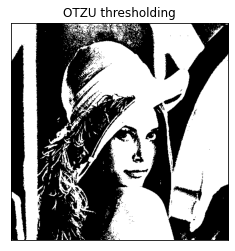

Threshold value found by Otsu's algorithm:  105.0


In [4]:
# Thresholding with maxval=255
ret,otzu_thresh = cv2.threshold(src,T,maxval,cv2.THRESH_OTSU)

# Plot the images
images = [src, otzu_thresh]
plt.title('OTZU thresholding')
plt.imshow(otzu_thresh, cmap = 'gray')
plt.show(plt.xticks([]), plt.yticks([]))

print("Threshold value found by Otsu's algorithm: ", ret)

We can compute the Otsu threshold by applying the single steps

In [5]:
# Set total number of bins in the histogram
bins_num = 256 
# Get the image histogram
hist, bin_edges = np.histogram(src, bins=bins_num)

# Get normalized histogram if it is required
#if is_normalized:
    #hist = np.divide(hist.ravel(), hist.max())

# Calculate centers of bins
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2.

# Iterate over all thresholds (indices) and get the probabilities w1(t), w2(t)
weight1 = np.cumsum(hist)
weight2 = np.cumsum(hist[::-1])[::-1]

# Get the class means mu0(t)
mean1 = np.cumsum(hist * bin_mids) / weight1
# Get the class means mu1(t)
mean2 = (np.cumsum((hist * bin_mids)[::-1]) / weight2[::-1])[::-1]

inter_class_variance = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:]) ** 2
# Maximize the inter_class_variance function val

index_of_max_val = np.argmax(inter_class_variance)
threshold = bin_mids[:-1][index_of_max_val]
print("Threshold value found by Otsu's algorithm:", threshold)


Threshold value found by Otsu's algorithm: 105.69140625


#Adaptive Thresholding
In some cases it’s too harsh to take just one value of threshold and apply it to all parts of an image. What if we have a picture with various amount of lighting in different areas? In this case, applying one value to the whole image would be a bad choice. A better approach would be using different thresholds for each part of the image. There is another technique called **Adaptive thresholding**, which calculates the threshold within the neighborhood area of the image, thus achieving a better result from images with varying illumination.

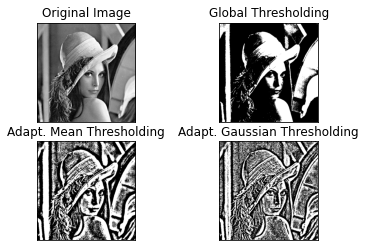

In [6]:
T=127
maxval=255

#Size of a neighborhood (3, 5, 7, ...) that is used to calculate a threshold 
#value for each pixel
blocksize=35 

#Global Thresholding
ret,th1 = cv2.threshold(src,T,maxval,cv2.THRESH_BINARY)

#Adaptive Thresholding using Mean
#For each pixel (x,y) the threshold value T(x,y) is computed as 
#a mean of the neighborhood of (x,y) minus C
th2 = cv2.adaptiveThreshold(src,maxval,cv2.ADAPTIVE_THRESH_MEAN_C,\
                            cv2.THRESH_BINARY,blocksize,C=0)
# C is a constant that is subtracted from the mean. 
# Normally, it is positive but may be zero or negative as well.

#Adaptive Thresholding using Gaussian
#For each pixel (x,y) the threshold value T(x,y) is computed as 
#a weighted sum (cross-correlation with a Gaussian window) 
#of the neighborhood of (x,y) minus C
th3 = cv2.adaptiveThreshold(src,maxval,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,blocksize,C=0)

titles = ['Original Image', 'Global Thresholding',
            'Adapt. Mean Thresholding', 'Adapt. Gaussian Thresholding']
images = [src, th1, th2, th3]

for i in range(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()